# Notebook 04: Exploratory Data Analysis

## Step 1: Environment Setup & Spark Session

In [1]:
import os, sys
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder \
    .appName("SmartCityBusClustering_EDA") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/24 09:23:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/24 09:23:57 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/07/24 09:23:57 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


Spark version: 4.1.1


## Step 2: Project Paths & Load Cleaned Dataset

In [2]:
PROJECT_ROOT = "/Users/aayushbohara/Desktop/smartcity-bus-clustering"
CLEANED_PATH = os.path.join(PROJECT_ROOT, "data/processed/cleaned_dataset.csv")
DB_PATH = os.path.join(PROJECT_ROOT, "data/database/bus_clustering.db")

df = spark.read.csv(CLEANED_PATH, header=True, inferSchema=True)
df.createOrReplaceTempView("bus_data")

print("Row count:", df.count())
df.printSchema()

Row count: 771733
root
 |-- timestamp: timestamp (nullable = true)
 |-- lineRef: string (nullable = true)
 |-- directionRef: string (nullable = true)
 |-- vehicleRef: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- location_source_file: string (nullable = true)
 |-- lineName: string (nullable = true)
 |-- serviceCode: string (nullable = true)
 |-- operator: string (nullable = true)
 |-- nationalOperatorCode: string (nullable = true)
 |-- origin: string (nullable = true)
 |-- destination: string (nullable = true)
 |-- vehicleJourneyCode: string (nullable = true)
 |-- departureTime: timestamp (nullable = true)
 |-- journeyPatternRef: string (nullable = true)
 |-- timetable_source_file: string (nullable = true)
 |-- fare_organisation: string (nullable = true)
 |-- common_product_type: string (nullable = true)
 |-- common_tariff_basis: string (nullable = true)
 |-- common_product_name: string (nullable = true)
 |-- fare_product

## Step 3: Overview Statistics (describe)

In [3]:
df.select("latitude", "longitude", "disruption_count", "fare_product_count").describe().show()

26/07/24 09:24:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-------------------+-------------------+-----------------+------------------+
|summary|           latitude|          longitude| disruption_count|fare_product_count|
+-------+-------------------+-------------------+-----------------+------------------+
|  count|             771733|             771733|           771733|            771733|
|   mean|  53.49076050274884|-2.2706040889258556|51.88175573676388|1073.9602090360268|
| stddev|0.05806558085000601| 0.1402457884830084|0.845799264148555|1806.5201584034305|
|    min|          53.338156|          -2.723324|               47|                 0|
|    max|          53.660219|          -1.782319|               53|              4182|
+-------+-------------------+-------------------+-----------------+------------------+



## Step 4: Statistical Measures (mean, stddev, skewness, kurtosis)

In [4]:
from pyspark.sql.functions import mean, stddev, skewness, kurtosis

df.select(
    mean("latitude").alias("mean_lat"), stddev("latitude").alias("std_lat"),
    skewness("latitude").alias("skew_lat"), kurtosis("latitude").alias("kurt_lat"),
    mean("longitude").alias("mean_lon"), stddev("longitude").alias("std_lon"),
    skewness("longitude").alias("skew_lon"), kurtosis("longitude").alias("kurt_lon"),
    mean("disruption_count").alias("mean_disr"), stddev("disruption_count").alias("std_disr"),
    skewness("disruption_count").alias("skew_disr"), kurtosis("disruption_count").alias("kurt_disr")
).show(truncate=False)

+-----------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+------------------+-----------------+-----------------+----------------+------------------+
|mean_lat         |std_lat            |skew_lat           |kurt_lat           |mean_lon           |std_lon           |skew_lon          |kurt_lon          |mean_disr        |std_disr         |skew_disr       |kurt_disr         |
+-----------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+------------------+-----------------+-----------------+----------------+------------------+
|53.49076050274884|0.05806558085000601|0.04837445379218232|-0.5229862103768359|-2.2706040889258556|0.1402457884830084|-0.869298330619191|0.6367021592167377|51.88175573676388|0.845799264148555|-3.2889358347726|11.965923007595583|
+-----------------+-------------------+-------------------+-------------------+-----

## Step 5: Data Profiling — Null Counts & Cardinality

In [6]:
from pyspark.sql.functions import countDistinct, sum as spark_sum, when

# cardinality per key column
df.select([countDistinct(c).alias(c) for c in ["lineRef", "vehicleRef", "nationalOperatorCode", "operator"]]).show()

# null percentage per column
total = df.count()
null_pct = df.select([
    (spark_sum(when(col(c).isNull(), 1).otherwise(0)) / total * 100).alias(c) for c in df.columns
])
null_pct.show(truncate=False, vertical=True)

+-------+----------+--------------------+--------+
|lineRef|vehicleRef|nationalOperatorCode|operator|
+-------+----------+--------------------+--------+
|    266|      1401|                   4|       2|
+-------+----------+--------------------+--------+

-RECORD 0-----------------------------------
 timestamp             | 0.0                
 lineRef               | 0.0                
 directionRef          | 0.0                
 vehicleRef            | 0.0                
 latitude              | 0.0                
 longitude             | 0.0                
 location_source_file  | 0.0                
 lineName              | 0.3139686912442516 
 serviceCode           | 0.3139686912442516 
 operator              | 0.3139686912442516 
 nationalOperatorCode  | 0.3139686912442516 
 origin                | 0.3139686912442516 
 destination           | 0.3139686912442516 
 vehicleJourneyCode    | 0.3139686912442516 
 departureTime         | 0.3139686912442516 
 journeyPatternRef     |

## Step 6: Visualizations

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# --- Check the odd operator cardinality first ---
df.select("operator").distinct().show(truncate=False)

+--------------------+
|operator            |
+--------------------+
|TFGM Franchise Owner|
|Bee Network         |
|NULL                |
+--------------------+



### 6a. Geospatial Distribution of Vehicle Pings (Sampled)

Sampled points for plotting: 15509


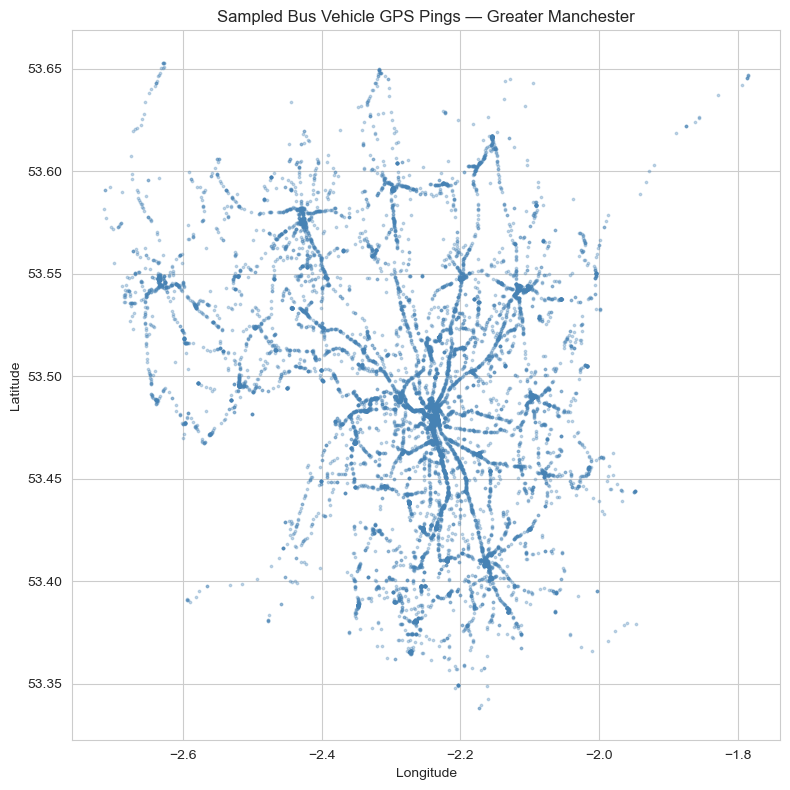

In [8]:
# Spark-side sampling BEFORE converting to Pandas - never collect 771k rows to the driver
geo_sample_pd = df.select("latitude", "longitude", "lineRef") \
    .sample(fraction=0.02, seed=42) \
    .toPandas()

print("Sampled points for plotting:", len(geo_sample_pd))

plt.figure(figsize=(8, 8))
plt.scatter(geo_sample_pd["longitude"], geo_sample_pd["latitude"], s=3, alpha=0.3, c="steelblue")
plt.title("Sampled Bus Vehicle GPS Pings — Greater Manchester")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

### 6b. Distribution of Disruption Count

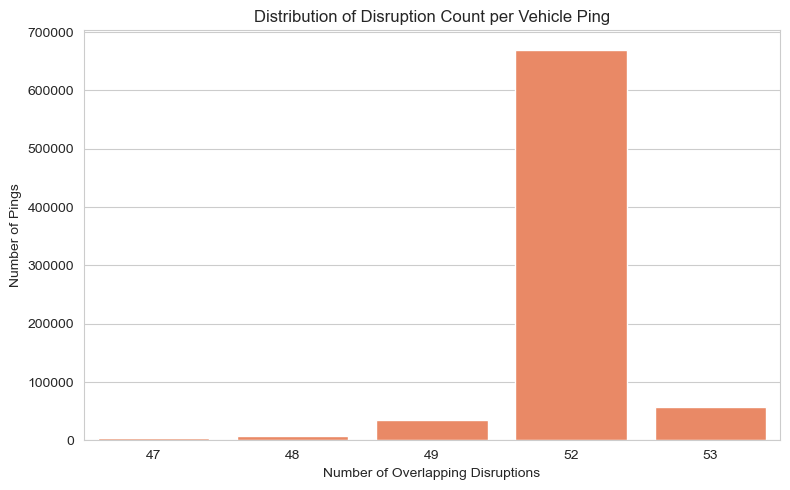

In [9]:
disruption_dist_pd = df.groupBy("disruption_count").count().orderBy("disruption_count").toPandas()

plt.figure(figsize=(8, 5))
sns.barplot(data=disruption_dist_pd, x="disruption_count", y="count", color="coral")
plt.title("Distribution of Disruption Count per Vehicle Ping")
plt.xlabel("Number of Overlapping Disruptions")
plt.ylabel("Number of Pings")
plt.tight_layout()
plt.show()

### 6c. Top 15 Lines by Ping Volume

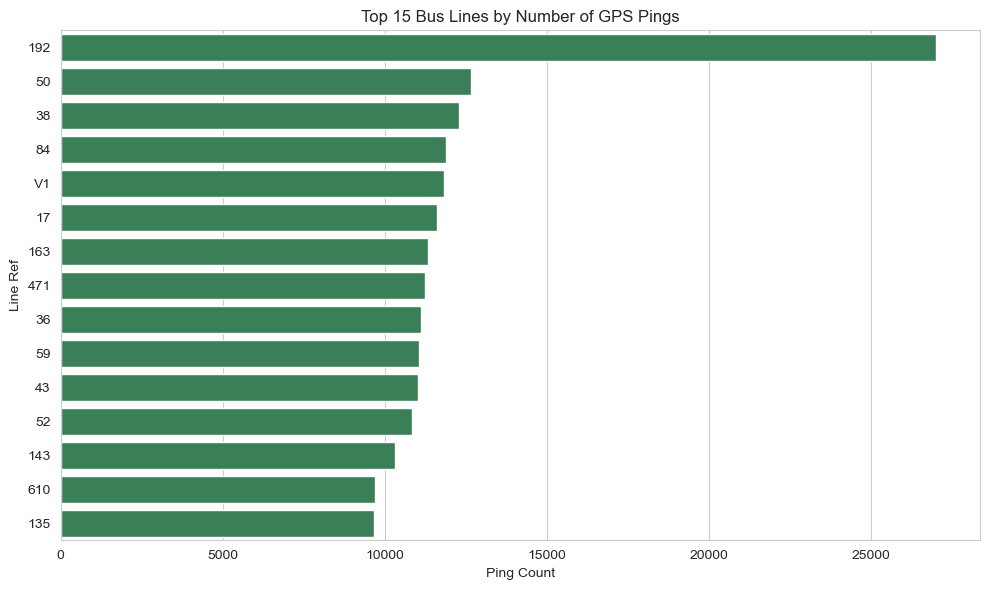

In [10]:
top_lines_pd = df.groupBy("lineRef").count().orderBy(col("count").desc()).limit(15).toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_lines_pd, y="lineRef", x="count", color="seagreen", order=top_lines_pd["lineRef"])
plt.title("Top 15 Bus Lines by Number of GPS Pings")
plt.xlabel("Ping Count")
plt.ylabel("Line Ref")
plt.tight_layout()
plt.show()

### 6d. Latitude vs Longitude Density (KDE)

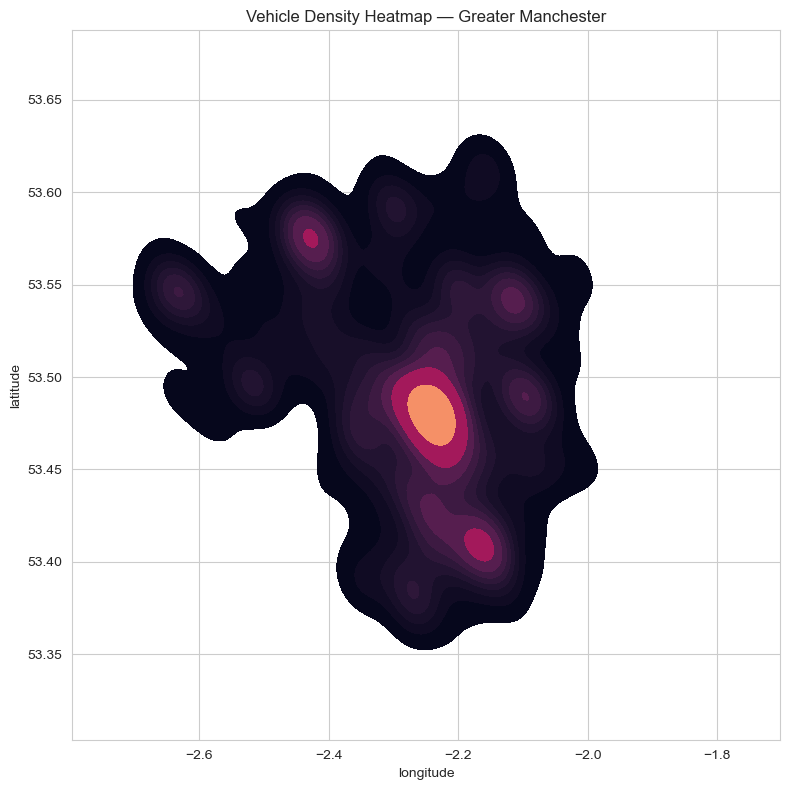

In [11]:
plt.figure(figsize=(8, 8))
sns.kdeplot(data=geo_sample_pd, x="longitude", y="latitude", cmap="rocket", fill=True, thresh=0.05)
plt.title("Vehicle Density Heatmap — Greater Manchester")
plt.tight_layout()
plt.show()

### 6e. Correlation Heatmap (Numeric Features)

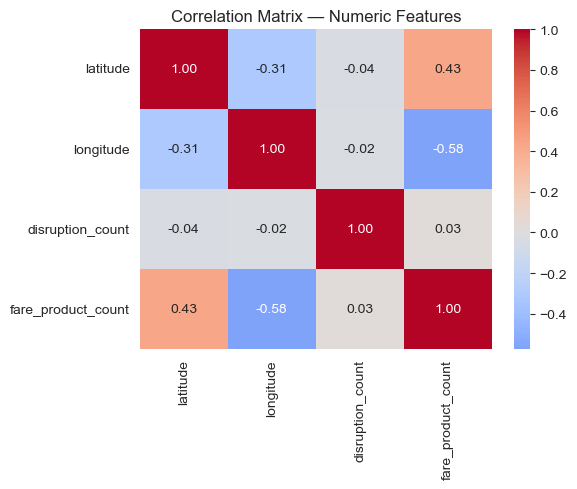

In [12]:
numeric_cols = ["latitude", "longitude", "disruption_count", "fare_product_count"]
corr_pd = df.select(numeric_cols).toPandas().corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_pd, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

### 6f. Ping Volume by Hour of Day

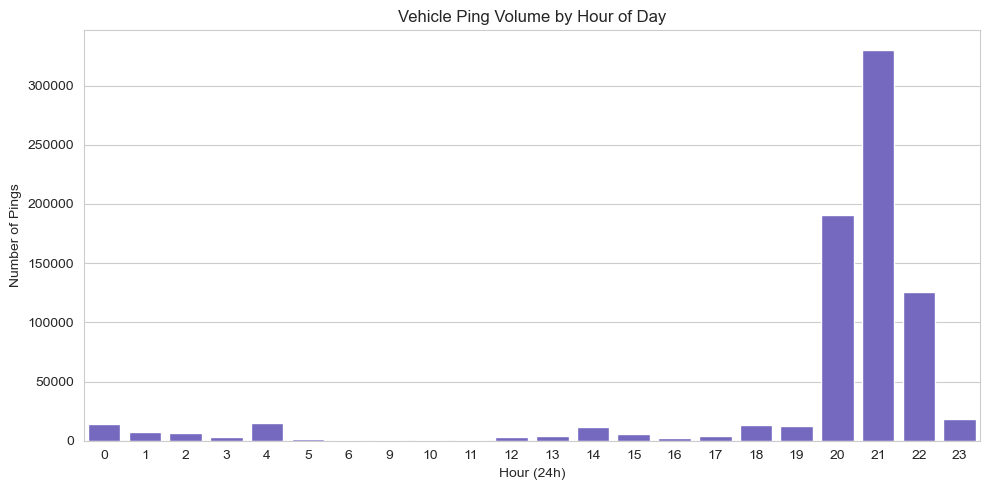

In [13]:
from pyspark.sql.functions import hour

hourly_pd = df.withColumn("hour", hour("timestamp")) \
    .groupBy("hour").count().orderBy("hour").toPandas()

plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_pd, x="hour", y="count", color="slateblue")
plt.title("Vehicle Ping Volume by Hour of Day")
plt.xlabel("Hour (24h)")
plt.ylabel("Number of Pings")
plt.tight_layout()
plt.show()